In [31]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import folium
from folium.plugins import HeatMap
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',None)
pd.set_option('display.max_rows', None)

In [148]:
df= pd.read_csv("C:/Users/akrit/Downloads/employee_experience_survey_data.csv")

In [149]:
df

,Name,Age Bracket,Gender,Ethnicity,Job Title,Department,Date Survey Completed,Job Satisfaction,Work-Life Balance,Management Support,Team Collaboration,Workload Fairness,Career Development Opportunities,Workplace Inclusivity,Company Communication,Compensation Satisfaction,Job Security,Overall Engagement
0,John Doe,25-34,Female,Asian,Product Manager,Product Development,2024-10-05,Disagree,Strongly Agree,Neutral,Neutral,Neutral,Disagree,Agree,Strongly Agree,Strongly Agree,Agree,Strongly Agree
1,Jane Smith,18-24,Female,Middle Eastern,Operations Manager,Sales,2024-10-07,Agree,Strongly Disagree,Strongly Agree,Neutral,Neutral,Disagree,Neutral,Neutral,Neutral,Agree,Neutral
2,Carlos Reyes,45-54,Female,Indian,UX Designer,Consulting,2024-10-08,Neutral,Strongly Disagree,Agree,Disagree,Strongly Agree,Agree,Agree,Strongly Disagree,Neutral,Strongly Agree,Strongly Agree
3,Emily Zhang,35-44,Male,Caucasian,UX Designer,HR,2024-10-07,Neutral,Agree,Agree,Strongly Disagree,Strongly Disagree,Strongly Agree,Agree,Strongly Disagree,Strongly Disagree,Agree,Neutral
4,Michael Johnson,18-24,Female,Caucasian,UX Designer,Product Development,2024-10-07,Agree,Strongly Agree,Disagree,Neutral,Strongly Disagree,Disagree,Disagree,Disagree,Strongly Disagree,Neutral,Disagree
5,Sara Ahmed,45-54,Male,Middle Eastern,Business Consultant,Operations,2024-10-09,Disagree,Strongly Disagree,Neutral,Neutral,Agree,Agree,Disagree,Neutral,Agree,Strongly Disagree,Neutral
6,Tom Davis,25-34,Male,Caucasian,UX Designer,HR,2024-10-08,Strongly Agree,Strongly Agree,Strongly Disagree,Strongly Agree,Strongly Agree,Strongly Disagree,Strongly Agree,Strongly Disagree,Neutral,Neutral,Agree
7,Linda Lopez,18-24,Male,African American,Customer Support,Product Development,2024-10-10,Disagree,Agree,Neutral,Strongly Disagree,Strongly Disagree,Agree,Neutral,Agree,Disagree,Disagree,Agree
8,Raj Patel,35-44,Female,Indian,Product Manager,IT,2024-10-07,Strongly Disagree,Strongly Agree,Strongly Disagree,Agree,Strongly Agree,Agree,Agree,Neutral,Agree,Strongly Agree,Disagree
9,Amara Njeri,18-24,Male,African American,HR Specialist,Design,2024-10-10,Strongly Agree,Strongly Agree,Agree,Agree,Strongly Agree,Strongly Disagree,Neutral,Agree,Neutral,Neutral,Strongly Disagree


In [150]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Name                              15 non-null     object
 1   Age Bracket                       15 non-null     object
 2   Gender                            15 non-null     object
 3   Ethnicity                         15 non-null     object
 4   Job Title                         15 non-null     object
 5   Department                        15 non-null     object
 6   Date Survey Completed             15 non-null     object
 7   Job Satisfaction                  15 non-null     object
 8   Work-Life Balance                 15 non-null     object
 9   Management Support                15 non-null     object
 10  Team Collaboration                15 non-null     object
 11  Workload Fairness                 15 non-null     object
 12  Career Development Oppor

In [151]:
# df.columns

df.columns= df.columns.str.strip().str.replace(" ","_").str.replace("-","_")


mapping the values 

In [155]:
from sklearn.preprocessing import LabelEncoder

l=LabelEncoder()

col=['Job_Satisfaction', 'Work_Life_Balance', 'Management_Support', 
     'Team_Collaboration', 'Workload_Fairness', 'Career_Development_Opportunities', 
     'Workplace_Inclusivity', 'Company_Communication', 'Compensation_Satisfaction', 
     'Job_Security', 'Overall_Engagement']



In [156]:
for columns in col:
    df[columns]=l.fit_transform(df[columns])

#### `descriptive statistics`

In [157]:
mean = df[col].mean()
mode= df[col].mode().iloc[0].values
medians= df[col].median()
standard= df[col].std()

In [158]:
stats_df= pd.DataFrame({'Mean':mean,'Mode':mode,'Medians':medians,'Standard Deviation':standard})

In [160]:
stats_df

,Mean,Mode,Medians,Standard Deviation
Job_Satisfaction,1.600000,0.0,1.0,1.404076
Work_Life_Balance,2.266667,3.0,3.0,1.624221
Management_Support,2.200000,4.0,2.0,1.656157
Team_Collaboration,2.200000,2.0,2.0,1.473577
Workload_Fairness,2.533333,2.0,3.0,1.125463
Career_Development_Opportunities,1.533333,0.0,1.0,1.641718
Workplace_Inclusivity,1.466667,2.0,2.0,1.125463
Company_Communication,2.200000,4.0,2.0,1.521278
Compensation_Satisfaction,1.800000,2.0,2.0,1.207122
Job_Security,1.400000,0.0,1.0,1.549193


In [161]:

age_mapping={'18-24':0,
             '25-34':1,
             '35-44':2,
             '45-54':3}

Gender_mapping={'Male':0,'Female':1}	
Department_mapping={'Product Development':0,
                    'Sales':1,
                    'Consulting':2,
                    'HR':3,
                    'Design':4,
                    'Finance':5,
                    'Operations':6,
                    'IT':7
                    }
Ethnicity_mapping={'Asian':0,
                   'Middle Eastern':1,
                   'Indian':2,
                   'Caucasian':3,
                   'African American':4,
                   'Hispanic':5}

In [ ]:
df['Age_Bracket']=df['Age_Bracket'].map(age_mapping)
df['Gender']=df['Gender'].map(Gender_mapping)
df['Department']=df['Department'].map(Department_mapping)
df['Ethnicity']=df['Ethnicity'].map(Ethnicity_mapping)


In [172]:
df

,Name,Age_Bracket,Gender,Ethnicity,Job_Title,Department,Date_Survey_Completed,Job_Satisfaction,Work_Life_Balance,Management_Support,Team_Collaboration,Workload_Fairness,Career_Development_Opportunities,Workplace_Inclusivity,Company_Communication,Compensation_Satisfaction,Job_Security,Overall_Engagement,Ethnicityt
0,John Doe,1,1,0,Product Manager,0,2024-10-05,1,3,2,2,2,1,0,3,3,0,3,0
1,Jane Smith,0,1,1,Operations Manager,1,2024-10-07,0,4,3,2,2,1,2,2,2,0,2,1
2,Carlos Reyes,3,1,2,UX Designer,2,2024-10-08,2,4,0,1,3,0,0,4,2,3,3,2
3,Emily Zhang,2,0,3,UX Designer,3,2024-10-07,2,0,0,4,4,3,0,4,4,0,2,3
4,Michael Johnson,0,1,3,UX Designer,0,2024-10-07,0,3,1,2,4,1,1,1,4,2,1,3
5,Sara Ahmed,3,0,1,Business Consultant,6,2024-10-09,1,4,2,2,0,0,1,2,0,4,2,1
6,Tom Davis,1,0,3,UX Designer,3,2024-10-08,3,3,4,3,3,4,3,4,2,2,0,3
7,Linda Lopez,0,0,4,Customer Support,0,2024-10-10,1,0,2,4,4,0,2,0,1,1,0,4
8,Raj Patel,2,1,2,Product Manager,7,2024-10-07,4,3,4,0,3,0,0,2,0,3,1,2
9,Amara Njeri,0,0,4,HR Specialist,4,2024-10-10,3,3,0,0,3,4,2,0,2,2,4,4


#### visualization

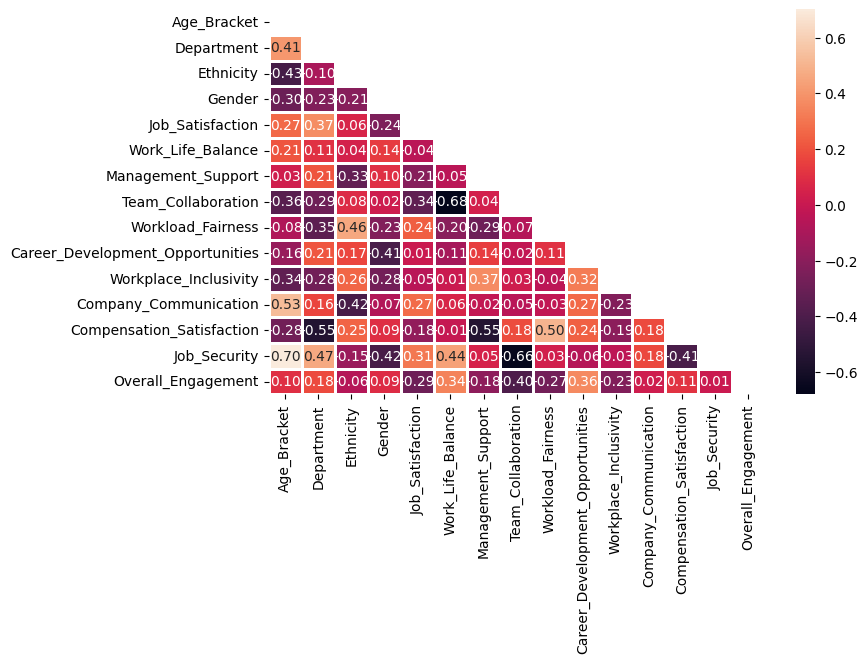

In [176]:
cols=['Age_Bracket','Department','Ethnicity','Gender','Job_Satisfaction', 'Work_Life_Balance', 'Management_Support', 
     'Team_Collaboration', 'Workload_Fairness', 'Career_Development_Opportunities', 
     'Workplace_Inclusivity', 'Company_Communication', 'Compensation_Satisfaction', 
     'Job_Security', 'Overall_Engagement']

plt.figure(figsize = (8, 5))
corr= df[cols].corr()
mask = np.triu(np.ones_like(corr, dtype = bool))

sns.heatmap(corr, mask = mask, linewidths = 1, annot = True,fmt=".2f")
plt.show()

#### Age_Bracket VS Work_Life_Balance

Text(0.5, 1.0, 'Age vs Work-Life Balance')

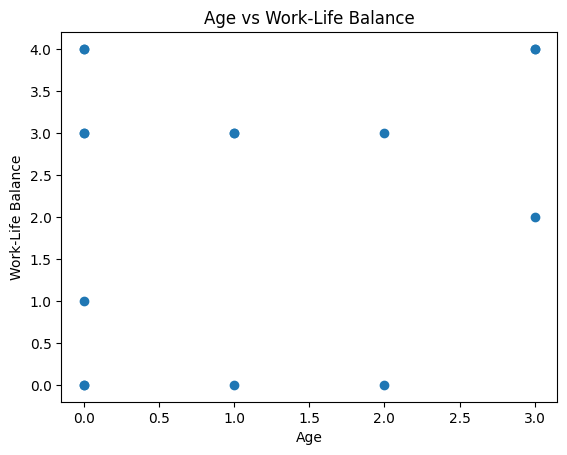

In [43]:
plt.scatter(df['Age_Bracket'], df['Work_Life_Balance'])
plt.xlabel('Age')
plt.ylabel('Work-Life Balance')
plt.title('Age vs Work-Life Balance')


##### Statistical Test

In [90]:
import statsmodels.api as sm

df['Intercept'] = 1
model = sm.OLS(df['Work_Life_Balance'], df[['Intercept', 'Age_Bracket']])
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:      Work_Life_Balance   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                 -0.031
Method:                 Least Squares   F-statistic:                    0.5773
Date:                Wed, 16 Oct 2024   Prob (F-statistic):              0.461
Time:                        19:33:08   Log-Likelihood:                -27.716
No. Observations:                  15   AIC:                             59.43
Df Residuals:                      13   BIC:                             60.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       1.9745      0.574      3.441      

#### `Task:Are employees in a certain age bracket or department more satisfied than others?`

In [209]:
fig = px.scatter(df, x='Job_Satisfaction', y='Age_Bracket', color='Job_Satisfaction',template='plotly_dark')


fig.update_xaxes(tickmode='linear', tick0=0, dtick=1)
fig.update_yaxes(tickmode='array', tickvals=df['Age_Bracket'].unique())

In [200]:
fig = px.scatter(df, x='Age_Bracket', y='Department', color='Job_Satisfaction',labels={'Job_Satisfaction': 'Job Satisfaction', 'Age_Bracket': 'Age Bracket'},template='plotly_dark')
fig.update_xaxes(tickmode='linear', tick0=0, dtick=1)
fig.update_yaxes(tickmode='array')
fig.show()

##### `Task:Does any demographic group (age, gender, ethnicity) show patterns in certain areas (e.g., Work-Life Balance or Compensation Satisfaction)?`

In [214]:
fig = px.box(df, x='Ethnicity', y='Compensation_Satisfaction', color='Ethnicity',title='Compensation Satisfaction by Ethnicity',template='plotly_dark',
             labels={'Compensation_Satisfaction': 'Compensation Satisfaction', 'Ethnicity': 'Ethnicity'})

fig.show()

fig = px.box(df, x='Gender', y='Compensation_Satisfaction', color='Gender',title='Compensation Satisfaction by Gender',template='plotly_dark',
             labels={'Compensation_Satisfaction': 'Compensation Satisfaction', 'Gender': 'Gender'})
fig.show()
